# Case Study — Does a multi-modal model beat an image-only baseline?

**The scenario.** An e-commerce company receives new products every month and needs each one classified against a fixed data contract before it feeds downstream ML models and executive/operational reports. Manual classification doesn't scale. The question this notebook answers: **does feeding the model a product's structured attributes (gender, color, season, usage) in addition to its photo actually improve classification over a photo-only model?**

The target is `subCategory` (27 classes) — a fine enough grain that structured attributes plausibly help, and close to what a real catalog data contract would require. See `01_eda.ipynb` for the class balance and the attribute-vs-target association analysis that motivated testing the multi-modal idea in the first place.

**Spoiler, stated upfront rather than buried:** the image-only baseline wins, consistently, across every configuration tested. This notebook walks through how that conclusion was reached -- including the two follow-up experiments run before accepting it.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.models import BaselineImageModel, MultiModalProductClassifier

ARTIFACTS = ROOT / "artifacts"
metrics = {name: json.loads((ARTIFACTS / f"metrics_{name}_summary.json").read_text()) for name in ("baseline", "proposed")}
class_names = metrics["baseline"]["class_names"]
print(f"{len(class_names)} subCategory classes, aggregated across seeds {metrics['baseline']['seeds']}")

27 subCategory classes, aggregated across seeds [0, 1, 2]


## Setup

- **Target:** `subCategory`, 27 classes after dropping anything under 100 samples (18 classes / 368 rows, 99.2% retained).
- **Attributes:** `gender` + `baseColour` + `season` + `usage`, concatenated into a 62-dim one-hot vector -- the closest analog to a real product data contract.
- **Models:** identical CNN trunk (3 conv blocks, BatchNorm, Dropout) for both; the proposed model adds an attribute MLP branch concatenated before the classifier head.
- **Rigor:** every number below is mean +/- std across 3 training seeds, with the data split itself held fixed (`SPLIT_SEED=42`) so seed variance isolates the architecture comparison, not the data partition.

In [2]:
print("Baseline -- image only:\n")
print(BaselineImageModel(num_classes=len(class_names)))
print("\n\nProposed -- image + attributes:\n")
print(MultiModalProductClassifier(num_classes=len(class_names), attr_dim=metrics["proposed"].get("attr_dim", 62)))

Baseline -- image only:

BaselineImageModel(
  (image_layer): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=6400, out_features=128, bias=T

## Results (25 epochs, full attribute set)

In [3]:
summary = pd.DataFrame({
    name: {
        "accuracy": f"{metrics[name]['accuracy']['mean']:.4f} +/- {metrics[name]['accuracy']['std']:.4f}",
        "macro_f1": f"{metrics[name]['macro_f1']['mean']:.4f} +/- {metrics[name]['macro_f1']['std']:.4f}",
        "weighted_f1": f"{metrics[name]['weighted_f1']['mean']:.4f} +/- {metrics[name]['weighted_f1']['std']:.4f}",
        "auto_tag_rate (>=0.85)": f"{metrics[name]['high_confidence_rate']['mean']:.4f} +/- {metrics[name]['high_confidence_rate']['std']:.4f}",
    }
    for name in ("baseline", "proposed")
}).T
summary

,accuracy,macro_f1,weighted_f1,auto_tag_rate (>=0.85)
baseline,0.9307 +/- 0.0003,0.8543 +/- 0.0021,0.9354 +/- 0.0001,0.8715 +/- 0.0078
proposed,0.8830 +/- 0.0092,0.8030 +/- 0.0071,0.8972 +/- 0.0052,0.6343 +/- 0.0604


The baseline wins on every metric, with much lower run-to-run variance. That asymmetry in variance matters as much as the means: the baseline converges to essentially the same solution every run, the proposed model does not.

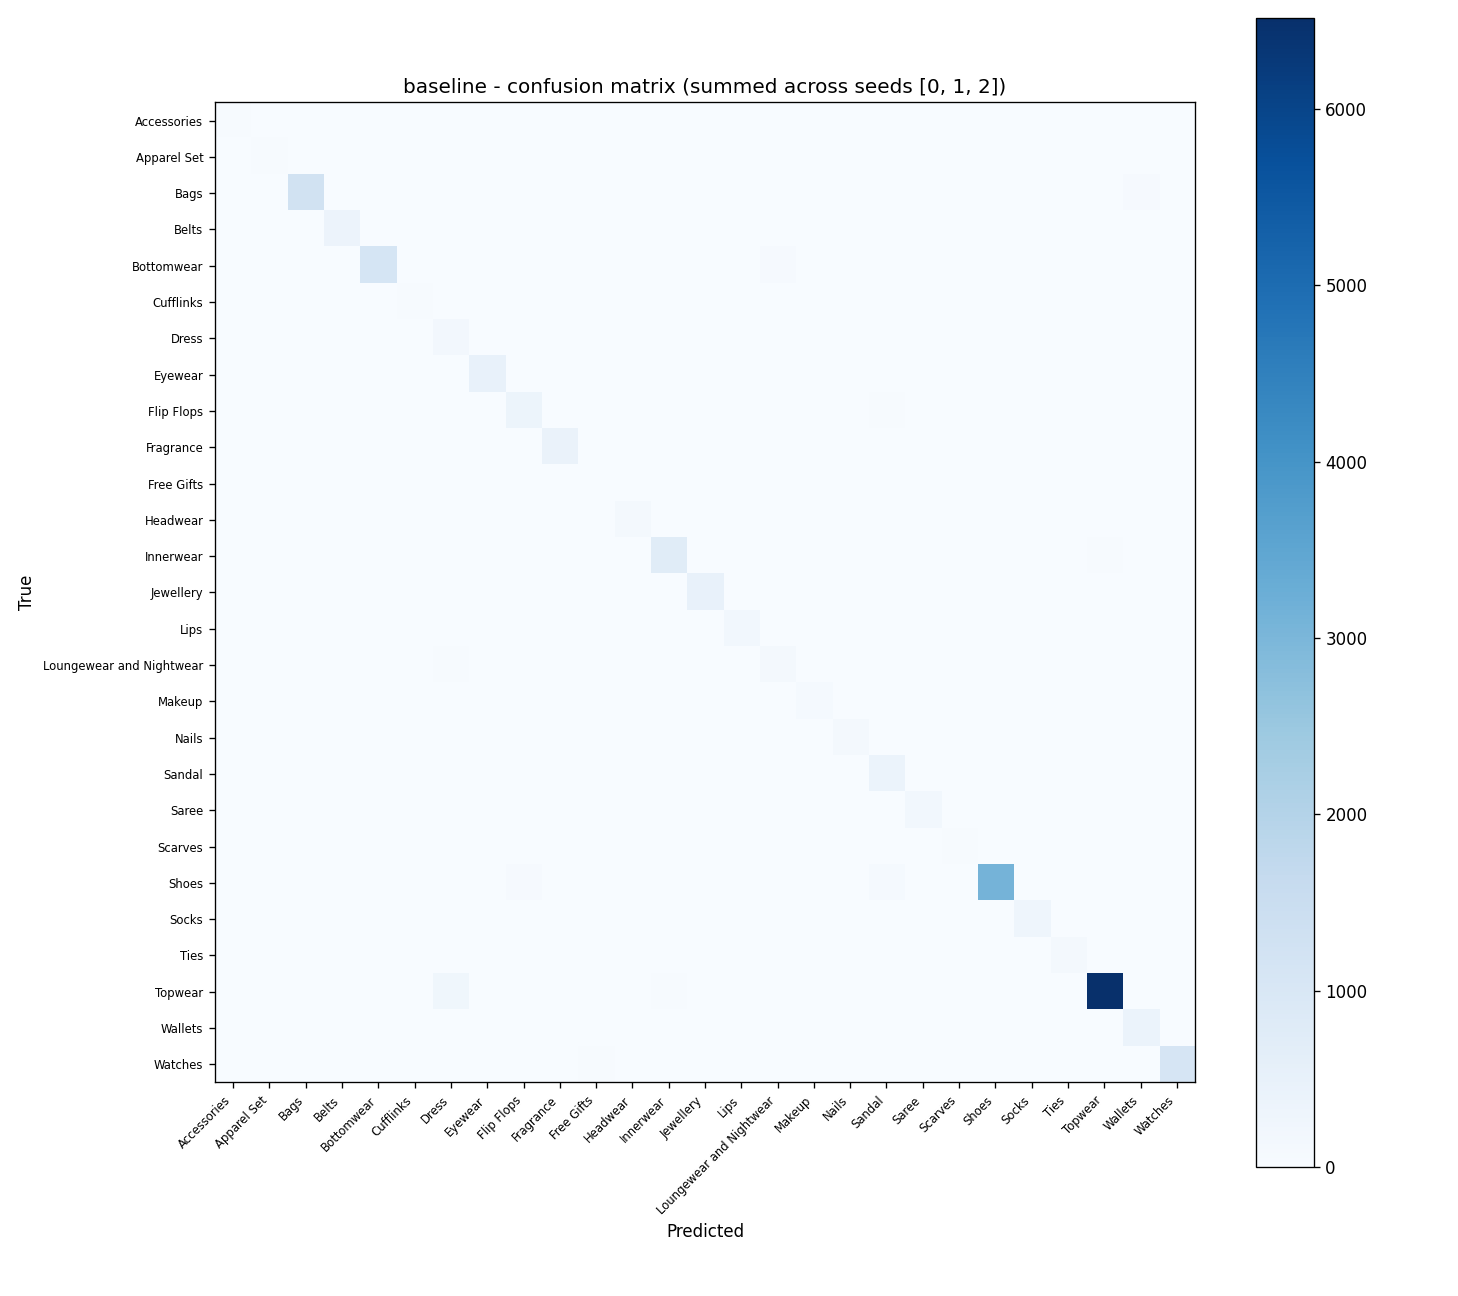

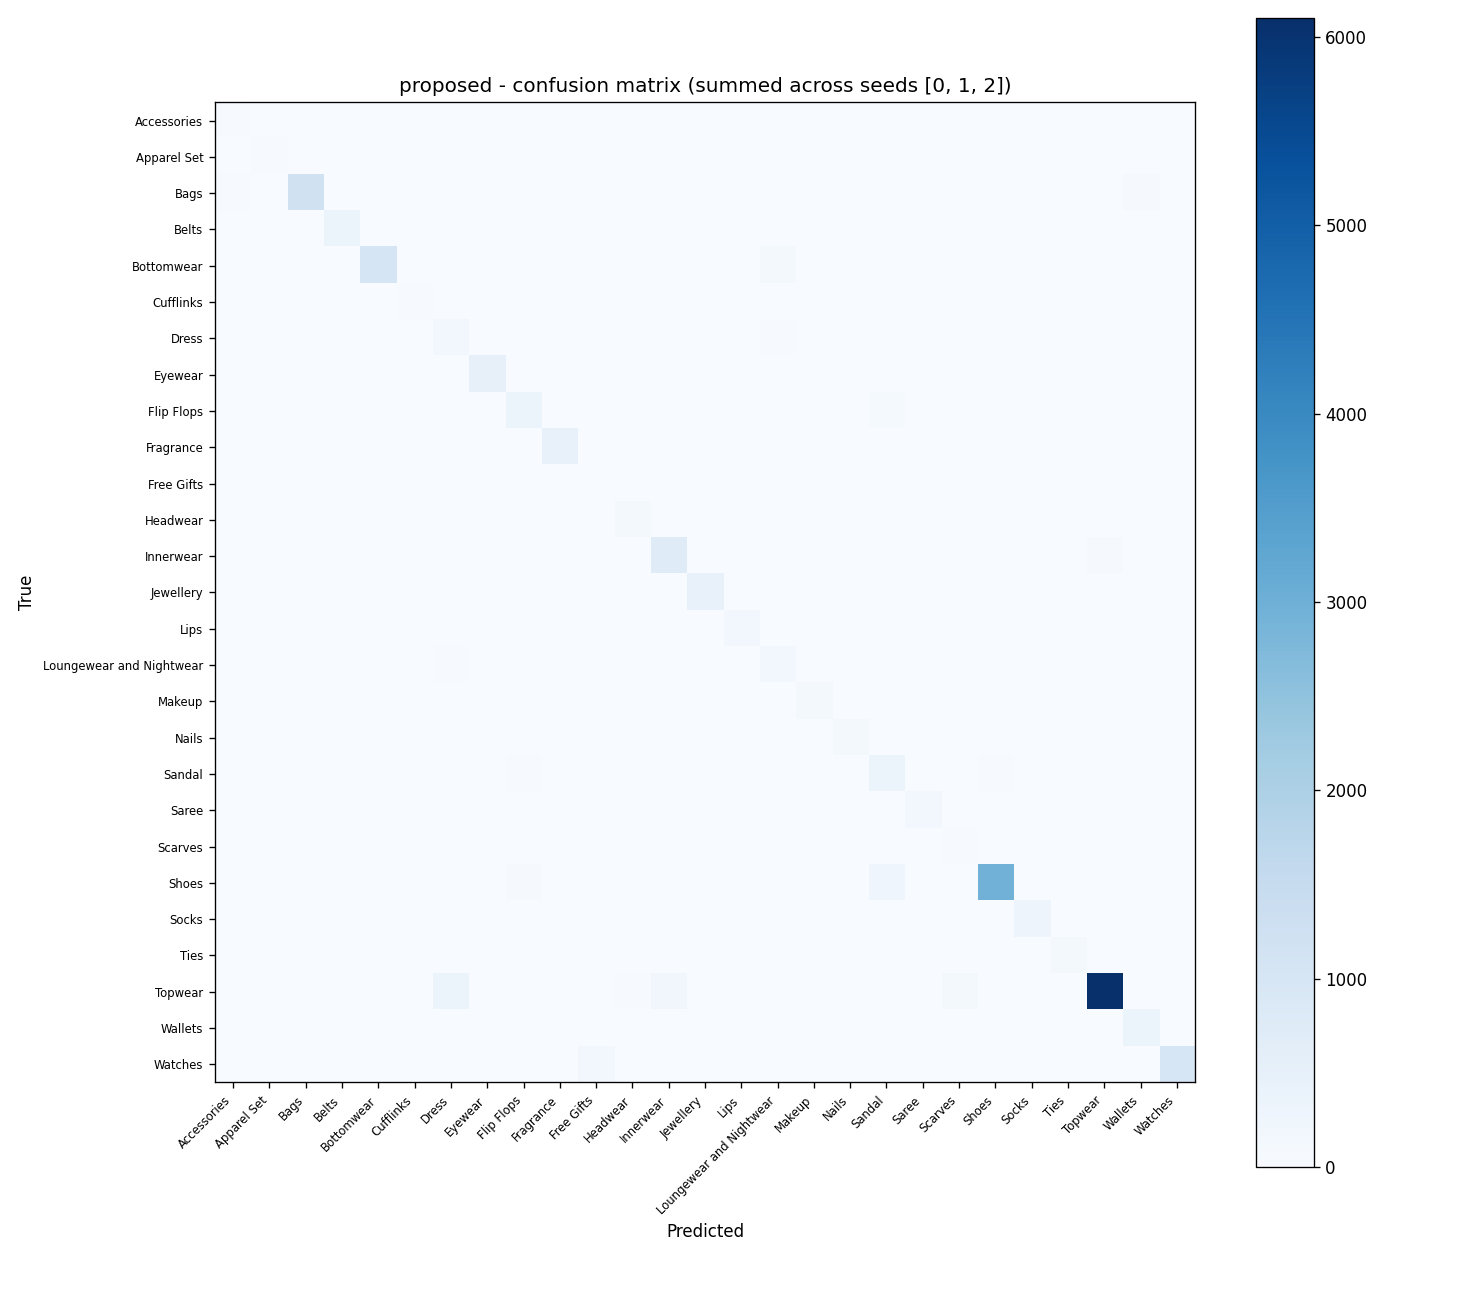

In [4]:
display(Image(filename=str(ARTIFACTS / "confusion_matrix_baseline_summary.png")))
display(Image(filename=str(ARTIFACTS / "confusion_matrix_proposed_summary.png")))

## Before accepting that conclusion: two follow-up experiments

A result that only shows up in one configuration is weak evidence. Two legitimate, pre-specified follow-ups were run rather than tuning until something looked better.

### 1. Attribute ablation

Maybe a smaller, less noisy attribute set helps -- `baseColour` (46 categories) is a plausible source of diluting noise. Tested gender-only and gender+season+usage against the full set (10 epochs, 3 seeds each):

In [5]:
ablation_rows = [
    ("baseline", "-", 0.8629, 0.0166, 0.7860, 0.0137),
    ("proposed", "all 4 attrs", 0.8388, 0.0216, 0.7429, 0.0355),
    ("proposed", "gender", 0.8161, 0.0054, 0.7352, 0.0200),
    ("proposed", "gender+season+usage", 0.8003, 0.0810, 0.7381, 0.0685),
]
ablation_df = pd.DataFrame(ablation_rows, columns=["model", "attributes", "accuracy_mean", "accuracy_std", "macro_f1_mean", "macro_f1_std"])
ablation_df

,model,attributes,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std
0,baseline,-,0.8629,0.0166,0.7860,0.0137
1,proposed,all 4 attrs,0.8388,0.0216,0.7429,0.0355
2,proposed,gender,0.8161,0.0054,0.7352,0.0200
3,proposed,gender+season+usage,0.8003,0.0810,0.7381,0.0685


No subset beat the baseline. The gender+season+usage variant was also the *least stable* of all four rows -- one seed collapsed to 68.6% accuracy while the other two reached ~85.8%, an order of magnitude more variance than the baseline ever shows. Dropping `baseColour` didn't fix anything; it just made training less reliable.

### 2. More training time

Maybe the proposed model -- deeper, with an extra branch -- just needed longer to converge than the baseline. Re-ran both models at 25 epochs instead of 10 (these are the numbers in the Results section above). Both models improved, but the baseline improved *more*, and its variance shrank to near zero while the proposed model's did not. More training time was not the bottleneck -- if anything, it confirmed the gap is real.

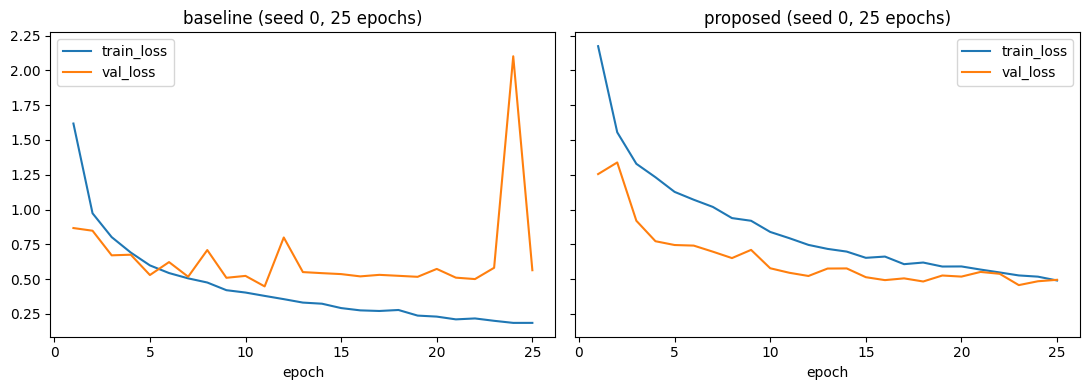

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, ("baseline", "proposed")):
    history = json.loads((ARTIFACTS / f"history_{name}_seed0.json").read_text())
    hist_df = pd.DataFrame(history["epochs"]).set_index("epoch")
    ax.plot(hist_df.index, hist_df["train_loss"], label="train_loss")
    ax.plot(hist_df.index, hist_df["val_loss"], label="val_loss")
    ax.set_title(f"{name} (seed 0, 25 epochs)")
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.show()

### 3. Per-class breakdown

The proposed model isn't uniformly worse -- it's worth checking where, specifically, it helps or hurts.

In [7]:
deltas = {
    c: metrics["proposed"]["per_class_f1"][c]["mean"] - metrics["baseline"]["per_class_f1"][c]["mean"]
    for c in class_names
}
delta_df = pd.DataFrame({
    "category": list(deltas.keys()),
    "f1_delta (proposed - baseline)": list(deltas.values()),
    "support": [metrics["proposed"]["per_class_support"][c] for c in deltas],
}).sort_values("f1_delta (proposed - baseline)")
print("Worst regressions:")
display(delta_df.head(5))
print("Best (small) wins:")
display(delta_df.tail(5))

Worst regressions:


,category,f1_delta (proposed - baseline),support
20,Scarves,-0.275875,18
11,Headwear,-0.150885,44
0,Accessories,-0.149337,19
18,Sandal,-0.148731,144
10,Free Gifts,-0.135277,16


Best (small) wins:


,category,f1_delta (proposed - baseline),support
19,Saree,0.004115,64
23,Ties,0.004927,38
5,Cufflinks,0.009364,16
16,Makeup,0.025100,39
1,Apparel Set,0.028382,16


A handful of low-support classes (Apparel Set, Makeup, Cufflinks, Ties, Saree) get marginally better F1 with the attribute branch (+0.004 to +0.028). But the losses are larger and more numerous (Scarves -0.276, Headwear -0.151, Accessories -0.149, Sandal -0.149, Free Gifts -0.135). The attribute branch doesn't add a targeted lift even on the classes where the EDA suggested an attribute might help. At this target grain, the photo already carries most of the signal, and naive concatenation gives the model no way to learn when to ignore a weak attribute.

## The agent layer (unaffected by which vision model wins)

The local agent's `classify_product` tool calls whichever model is configured as `VISION_MODEL` in `src/agent.py` -- currently `"proposed"`, simply because that's the multi-modal architecture this case study is about. The `search_similar_products` tool is a pure text-retrieval RAG lookup over catalog metadata and is unaffected by either model.

In [8]:
from src.agent import chat

result = chat("Do you have any black formal bags?")
print("Tool calls made:", [t["tool"] for t in result["tool_trace"]])
print()
print(result["reply"])

C:\Users\vitor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import issparse


Tool calls made: ['search_similar_products']

Here are some black formal bags:

* Ivor Tag Black & White Striped Sling Bag
* Baggit Women Black Handbag
* Bulchee Women Black Handbag
* Baggit Women Posh Taj Black Handbag
* Wildcraft Unisex Black Lunch Bag
* Baggit Women Black Purse

These are all formal black bags that you might be interested in. Let me know if you need more information or help with anything else!


## Conclusion and next steps

**Production recommendation: the image-only baseline.** It's more accurate, has a much higher usable auto-tag rate (87% vs. 63%), and is dramatically more stable across retrains -- all properties that matter more than "uses more of the available data" for a system feeding executive and operational reports.

This is a legitimate negative result for the multi-modal hypothesis *at this target grain, with this fusion mechanism* -- not a failed project. Next steps that could still change the picture, in roughly descending order of how promising they seem:

- A gating/attention fusion mechanism instead of plain concatenation, so the model can learn to downweight irrelevant attributes per example.
- `articleType` (141 raw classes) -- a finer grain where attributes might correlate more tightly with the target than they do at `subCategory`.
- Two-head multi-task output (`masterCategory` + `subCategory` together).
- Confidence calibration before trusting the auto-tag rate as an operational number.